Project Title:- E-Commerce Sales Analysis & Business Insights

The objective of this project is to analyze e-commerce sales data to identify key revenue drivers, profitable segments, and areas of loss to support better business decision-making.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Loading dataset and understanding its structure

In [3]:
data = pd.read_csv('SampleSuperstore.csv')
data.head()
data.shape
data.info()
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Qua

In [4]:
data.duplicated().sum()

17

In [5]:
data.drop_duplicates(inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9977 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9977 non-null   object 
 1   Segment       9977 non-null   object 
 2   Country       9977 non-null   object 
 3   City          9977 non-null   object 
 4   State         9977 non-null   object 
 5   Postal Code   9977 non-null   int64  
 6   Region        9977 non-null   object 
 7   Category      9977 non-null   object 
 8   Sub-Category  9977 non-null   object 
 9   Sales         9977 non-null   float64
 10  Quantity      9977 non-null   int64  
 11  Discount      9977 non-null   float64
 12  Profit        9977 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1.1+ MB


In [7]:
print((data['Profit'] < 0).value_counts())
print((data['Sales'] < 0).value_counts())

Profit
False    8108
True     1869
Name: count, dtype: int64
Sales
False    9977
Name: count, dtype: int64


2. Feature Engineering

In [8]:
data['Profit Margin'] = data['Profit'] / data['Sales']
#If Profit < 0 → Loss Else → Profit
data['Loss Flag'] = data['Profit'].apply(lambda x: 'Loss' if x < 0 else 'Profit')
data.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margin,Loss Flag
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,0.1600,Profit
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,0.3000,Profit
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,0.4700,Profit
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-0.4000,Loss
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,0.1125,Profit


3. .Exploratory Data Analysis (EDA)

i. Sales and Profit Overview

In [9]:
print("Total Sales: ", data['Sales'].sum())
print("Total Profit: ", data['Profit'].sum())
print("Average Profit: ", data['Profit'].mean())
print("Overall Profit Margin: ", data['Profit Margin'].sum())

Total Sales:  2296195.5903
Total Profit:  286241.4226
Average Profit:  28.69012955798336
Overall Profit Margin:  1198.372770774977


Insight:- 

The business is overall profitable, with positive total profit and a stable profit margin. This indicates that the company is generating more revenue than its costs, but there is still scope to improve efficiency and increase margins.

ii. Category-wise Performance Analysis

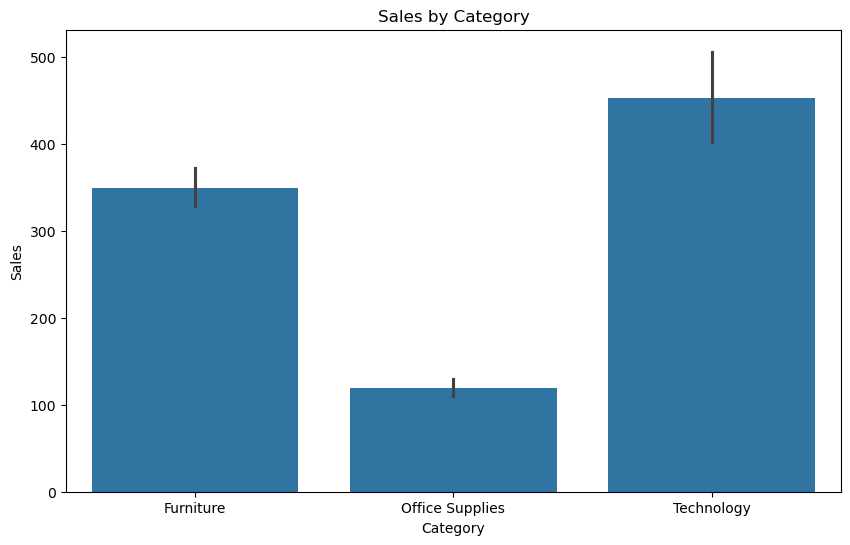

In [10]:
#Category vs Sales
plt.figure(figsize=(10,6))
sns.barplot(x='Category', y='Sales', data=data)
plt.title('Sales by Category')
plt.show()

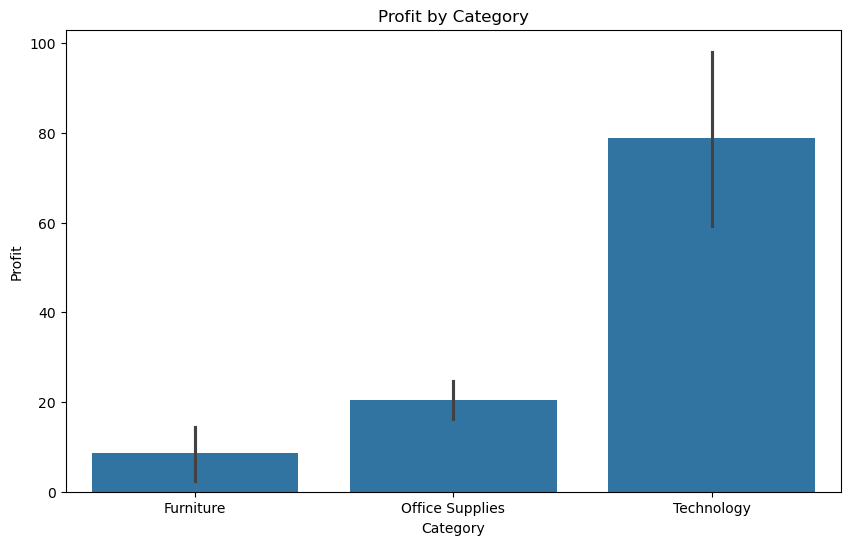

In [11]:
#Category vs Profit
plt.figure(figsize=(10,6))
sns.barplot(x='Category', y='Profit', data=data)
plt.title('Profit by Category')
plt.show()

Insight:- 

Technology dominates in both sales and profit, making it the most valuable category for the business. It consistently generates high revenue along with strong returns. Other categories contribute to sales, but their profitability is comparatively lower, indicating a need for better cost and pricing strategies.

iii. Sub-Category Analysis

In [12]:
#Top Profitable Sub Category
top_profitable_subcat = data.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
print("Top Profitable Sub-Category:\n", top_profitable_subcat.head(1))

print('\n')

#Top Loss Making Sub Category
top_loss_subcat = data.groupby('Sub-Category')['Profit'].sum().sort_values()
print("Top Loss Making Sub-Category:\n", top_loss_subcat.head(1))

Top Profitable Sub-Category:
 Sub-Category
Copiers    55617.8249
Name: Profit, dtype: float64


Top Loss Making Sub-Category:
 Sub-Category
Tables   -17725.4811
Name: Profit, dtype: float64


Insight:- 

Copiers are the most profitable sub-category, indicating strong demand and high margins. On the other hand, Tables are the most loss-making sub-category, suggesting issues in pricing, cost, or discount strategy. This shows that not all products contribute equally, and some areas require immediate attention to reduce losses.

iv. Region Analysis

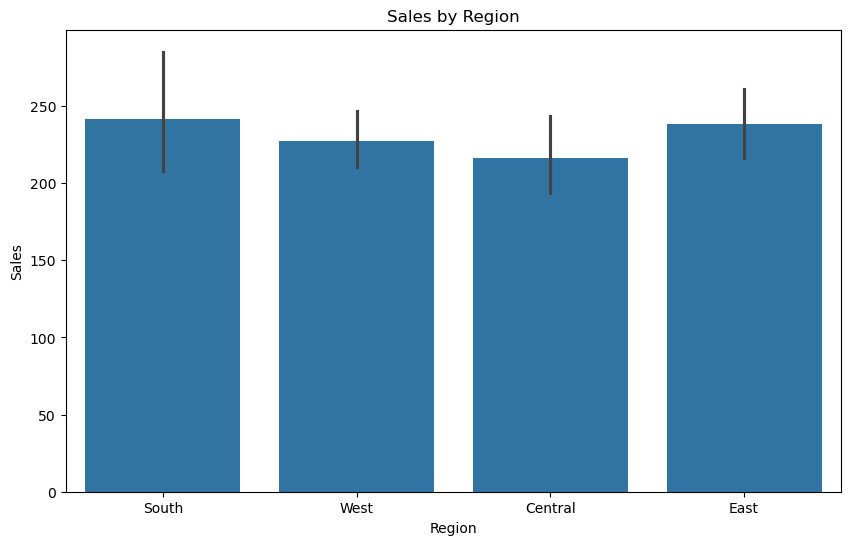

In [13]:
#Region vs Sales
plt.figure(figsize=(10,6))
sns.barplot(x='Region', y='Sales', data=data)
plt.title('Sales by Region')
plt.show()

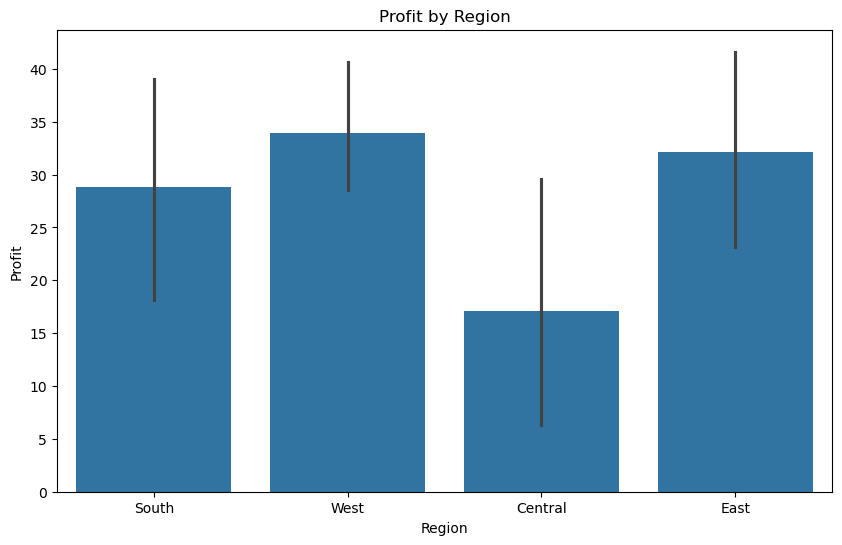

In [14]:
#Region vs Profit
plt.figure(figsize=(10,6))
sns.barplot(x='Region', y='Profit', data=data)
plt.title('Profit by Region')
plt.show()

Insight:-

South and East regions perform well in terms of sales, indicating strong customer demand in these areas. However, the West region generates the highest profit, which suggests better efficiency and cost management. This shows that high sales do not always translate into high profit, and different regions perform differently in terms of profitability

v. Discount Analysis

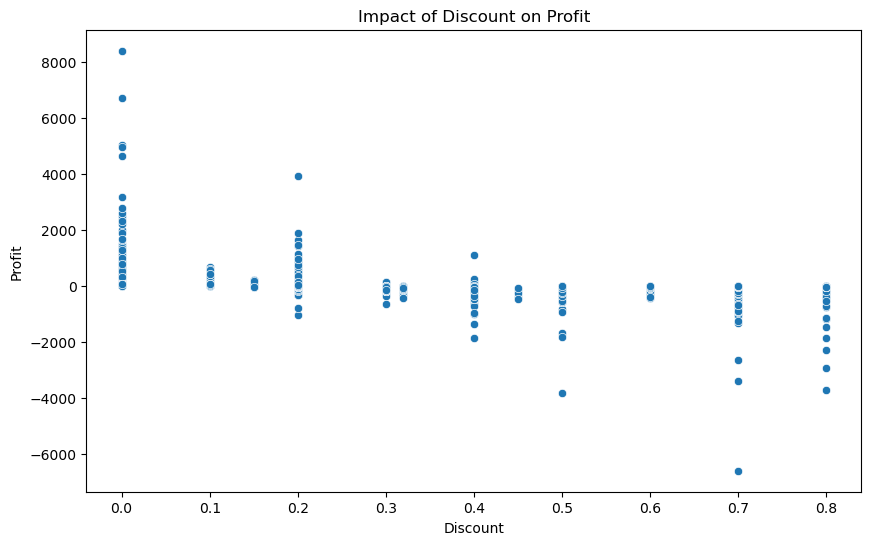

In [15]:
#Impact Of Discount on Profit
plt.figure(figsize=(10,6))
sns.scatterplot(x='Discount', y='Profit', data=data)
plt.title('Impact of Discount on Profit')
plt.show()

Insight:- 

There is a clear negative relationship between discount and profit. Lower discounts are associated with higher profits, while higher discounts often lead to losses. This indicates that excessive discounting is harming the business and reducing overall profitability

4. Data Visualization

i. Sales and Profit Overview

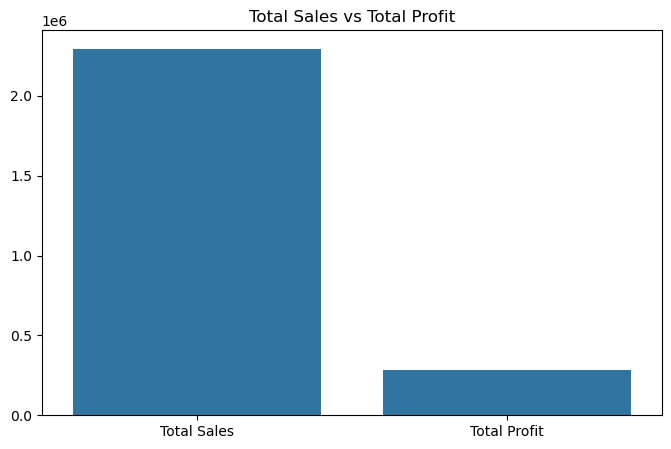

In [16]:
#Total Sales vs Total Profit
total_sales = data['Sales'].sum()
total_profit = data['Profit'].sum()
plt.figure(figsize=(8,5))
sns.barplot(x=['Total Sales', 'Total Profit'], y=[total_sales, total_profit])
plt.title('Total Sales vs Total Profit')
plt.show()

Insight:-

The business generates strong overall sales with positive profit, indicating a stable performance. However, there is still scope to improve profit margins.

ii. Category-wise Sales and Profit

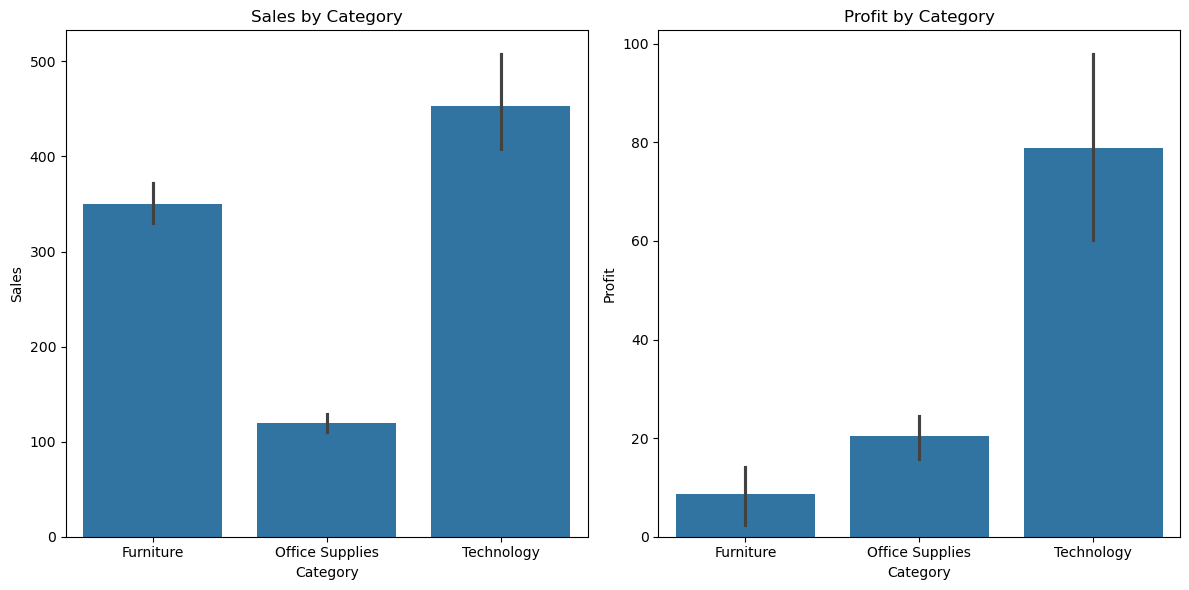

In [17]:
#Category vs Sales and Category vs Profit
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
sns.barplot(x='Category', y='Sales', data=data)
plt.title('Sales by Category')
plt.subplot(1, 2, 2)
sns.barplot(x='Category', y='Profit', data=data)
plt.title('Profit by Category')
plt.tight_layout()
plt.show()

Insight:- 

Technology leads in both sales and profit, making it the strongest category. Other categories contribute to revenue but are less efficient in terms of profitability.

iii. Sub-Category Performance

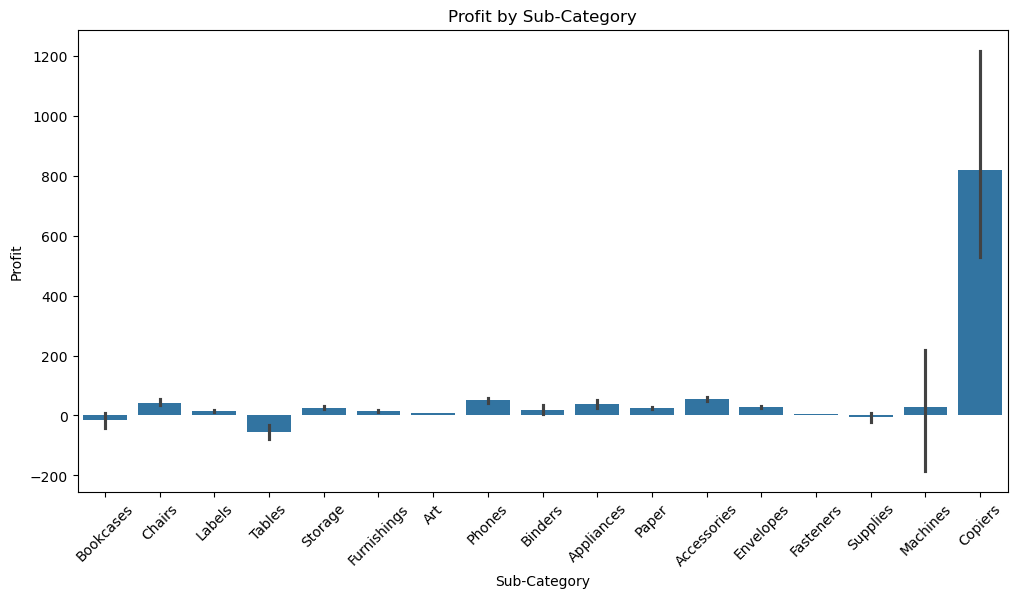

In [18]:
#Sub-Category vs Profit
plt.figure(figsize=(12,6))
sns.barplot(x='Sub-Category', y='Profit', data=data)
plt.title('Profit by Sub-Category')
plt.xticks(rotation=45)
plt.show()

Insight:- 

Copiers generate the highest profit, while Tables result in significant losses. This highlights the need to focus on profitable products and improve or rethink loss-making ones.

iv. Region-wise Performance

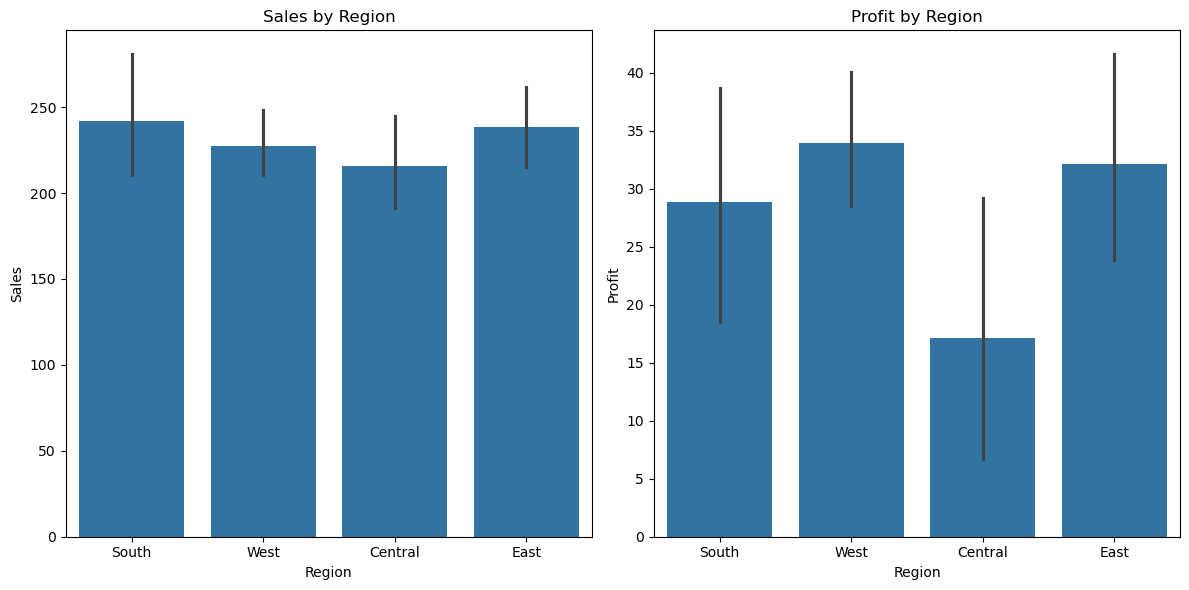

In [19]:
#Region vs Sales and Region vs Profit
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
sns.barplot(x='Region', y='Sales', data=data)
plt.title('Sales by Region')
plt.subplot(1, 2, 2)
sns.barplot(x='Region', y='Profit', data=data)
plt.title('Profit by Region')
plt.tight_layout()
plt.show()

Insight:-

South and East regions show strong sales performance, while the West region leads in profitability. This indicates differences in efficiency across regions.

v. Impact Of Discount on Profit

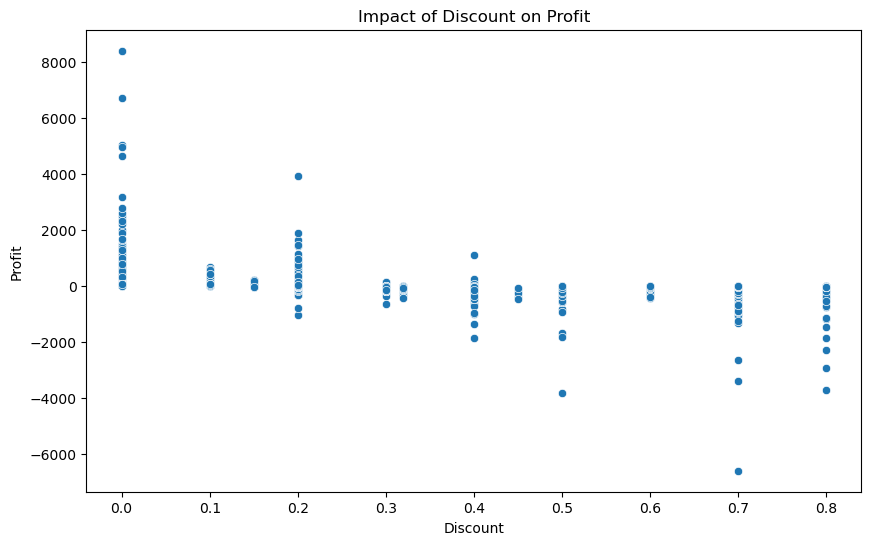

In [20]:
#Discount vs Profit
plt.figure(figsize=(10,6))
sns.scatterplot(x='Discount', y='Profit', data=data)
plt.title('Impact of Discount on Profit')
plt.show()

Insight:- 

Higher discounts are associated with lower profits and often lead to losses, while lower discounts help maintain profitability. This shows that excessive discounting negatively impacts business performance.

Key Insights:- 

1. The business is overall profitable, but profit margins can be improved by controlling costs and optimizing pricing strategies.

2. Technology is the most profitable category, while other categories contribute to sales but are less efficient in generating profit.

3. Copiers are the most profitable sub-category, whereas Tables are the biggest loss-making items, indicating the need for better pricing or cost control.

4. South and East regions generate high sales, but the West region is the most profitable, showing that higher sales do not always lead to higher profit.

5. Higher discounts negatively impact profit, and excessive discounting often leads to losses, highlighting the need for balanced discount strategies.


Conclusion

This project analyzed e-commerce sales data to identify key revenue drivers and areas of loss. The analysis showed that while the business is profitable overall, certain categories and products contribute more effectively than others. High-performing areas like Technology and Copiers drive profit, whereas items like Tables and high discount strategies lead to losses. The findings highlight the importance of data-driven decision making to improve profitability and optimize business performance.